# Heart Disease Prediction with Machine Learning | Test 1

## 1. introduction
The project predicts the presence of heart disease using clinical variables and machine learning models.

This is my first machine learning code; the goal for this proyect is to obtain the most accurate score with the most commonly used machine learning models in scikit-learn.


## 2. Dataset

The dataset contains clinical information from patiens: age, sex, chest pain type, resting BP, cholesterol levels, fasting BP, resting ECG, max HG, exercise angina, oldpeak and st slope.

Each row represents a patient, and the target variable indicates whether the patient has heart disease.

| Código  | Significado médico |
| ------- | ------------------ |
| **TA**  | Typical Angina     |
| **ATA** | Atypical Angina    |
| **NAP** | Non-Anginal Pain   |
| **ASY** | Asymptomatic       |


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

df = pd.read_csv("../data/heart.csv")

df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


## 3. Data Preprocessing

Categorical variables such as Sex and ChestPainType were converted into numerical format using one-hot encoding.

The dataset was then split into features (X) and target (y).

In [219]:
df_original = df.copy()

category_cols = ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"]
df = pd.get_dummies(df, columns=category_cols, dtype=int)

df.head(10)

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,140,289,0,172,0.0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
1,49,160,180,0,156,1.0,1,1,0,0,...,1,0,0,1,0,1,0,0,1,0
2,37,130,283,0,98,0.0,0,0,1,0,...,0,0,0,0,1,1,0,0,0,1
3,48,138,214,0,108,1.5,1,1,0,1,...,0,0,0,1,0,0,1,0,1,0
4,54,150,195,0,122,0.0,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1
5,39,120,339,0,170,0.0,0,0,1,0,...,1,0,0,1,0,1,0,0,0,1
6,45,130,237,0,170,0.0,0,1,0,0,...,0,0,0,1,0,1,0,0,0,1
7,54,110,208,0,142,0.0,0,0,1,0,...,0,0,0,1,0,1,0,0,0,1
8,37,140,207,0,130,1.5,1,0,1,1,...,0,0,0,1,0,0,1,0,1,0
9,48,120,284,0,120,0.0,0,1,0,0,...,0,0,0,1,0,1,0,0,0,1


In [220]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="HeartDisease")
y = df["HeartDisease"]


In [221]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



## 4. Exploratory Data Analysis (EDA)

Exploratory analysis helps understand the structure of the dataset and identify potential relationships between variables.

In [222]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   RestingBP          918 non-null    int64  
 2   Cholesterol        918 non-null    int64  
 3   FastingBS          918 non-null    int64  
 4   MaxHR              918 non-null    int64  
 5   Oldpeak            918 non-null    float64
 6   HeartDisease       918 non-null    int64  
 7   Sex_F              918 non-null    int64  
 8   Sex_M              918 non-null    int64  
 9   ChestPainType_ASY  918 non-null    int64  
 10  ChestPainType_ATA  918 non-null    int64  
 11  ChestPainType_NAP  918 non-null    int64  
 12  ChestPainType_TA   918 non-null    int64  
 13  RestingECG_LVH     918 non-null    int64  
 14  RestingECG_Normal  918 non-null    int64  
 15  RestingECG_ST      918 non-null    int64  
 16  ExerciseAngina_N   918 non-null    in

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_F,Sex_M,ChestPainType_ASY,...,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ExerciseAngina_N,ExerciseAngina_Y,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,...,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377,0.210240,0.789760,0.540305,...,0.221133,0.050109,0.204793,0.601307,0.193900,0.595861,0.404139,0.068627,0.501089,0.430283
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414,0.407701,0.407701,0.498645,...,0.415236,0.218289,0.403770,0.489896,0.395567,0.490992,0.490992,0.252957,0.500271,0.495386
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [223]:
df.isnull().sum()

Age                  0
RestingBP            0
Cholesterol          0
FastingBS            0
MaxHR                0
Oldpeak              0
HeartDisease         0
Sex_F                0
Sex_M                0
ChestPainType_ASY    0
ChestPainType_ATA    0
ChestPainType_NAP    0
ChestPainType_TA     0
RestingECG_LVH       0
RestingECG_Normal    0
RestingECG_ST        0
ExerciseAngina_N     0
ExerciseAngina_Y     0
ST_Slope_Down        0
ST_Slope_Flat        0
ST_Slope_Up          0
dtype: int64

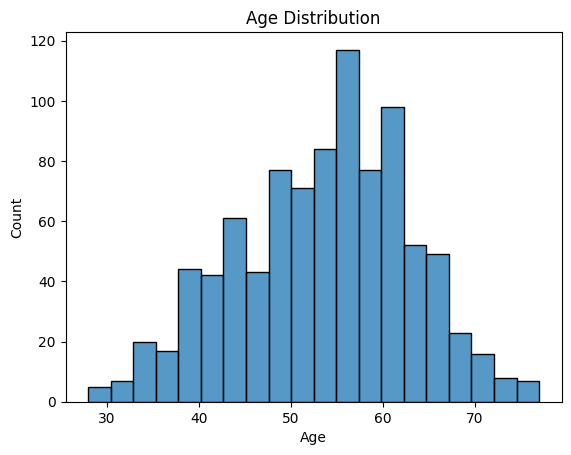

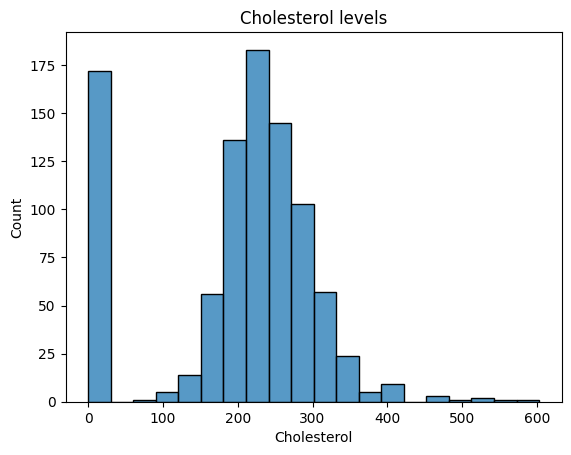

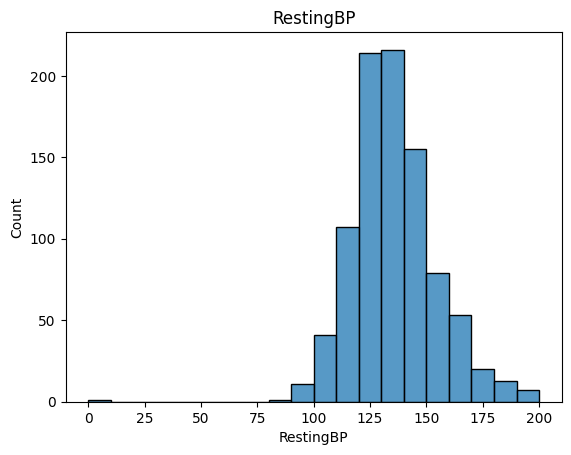

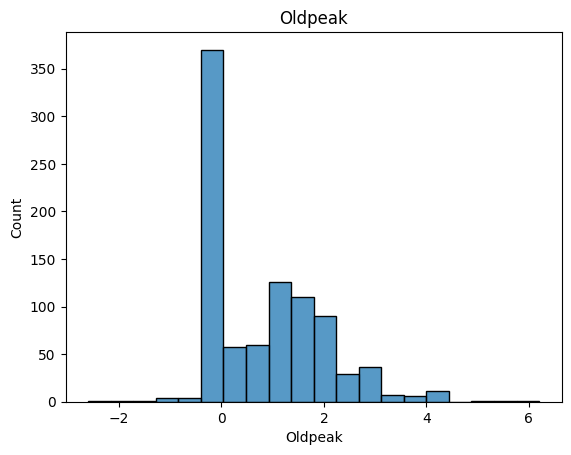

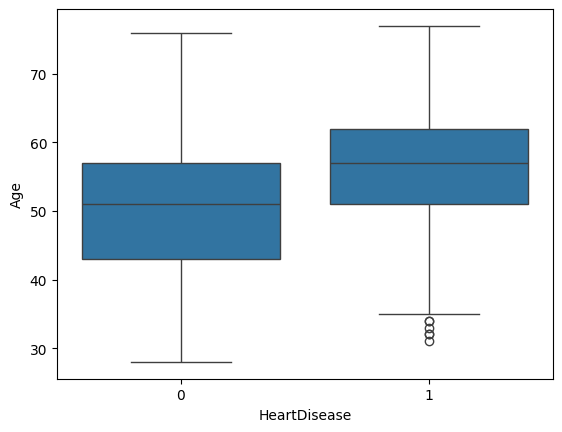

In [224]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_original["Age"], bins=20)
plt.title("Age Distribution")
plt.show()

sns.histplot(df_original["Cholesterol"], bins=20)
plt.title("Cholesterol levels")
plt.show()

sns.histplot(df_original["RestingBP"], bins=20)
plt.title("RestingBP")
plt.show()

sns.histplot(df_original["Oldpeak"], bins=20)
plt.title("Oldpeak")
plt.show()

sns.boxplot(x="HeartDisease", y="Age", data=df_original)
plt.show()


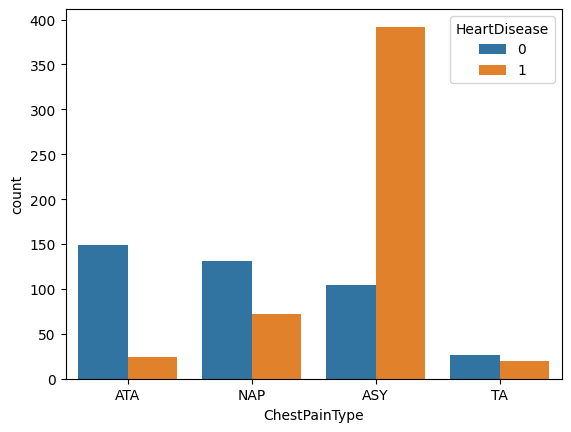

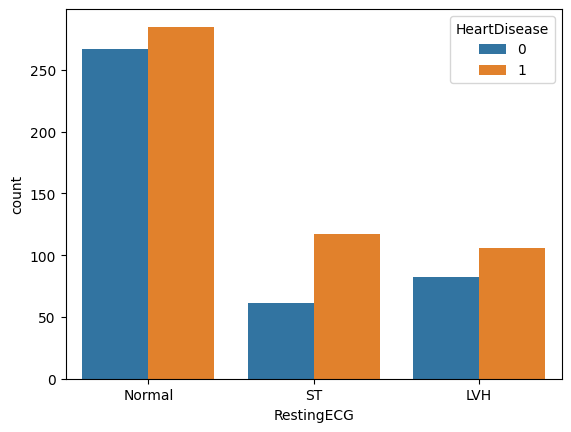

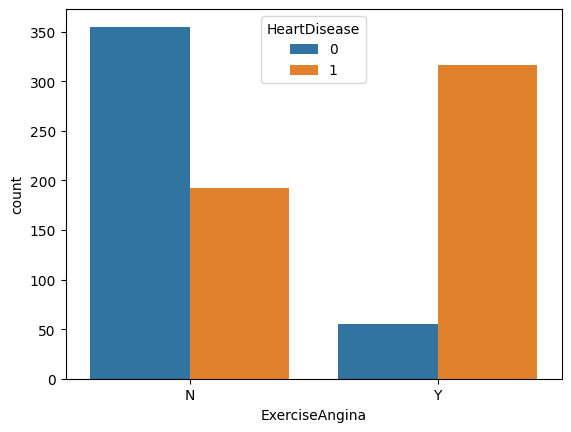

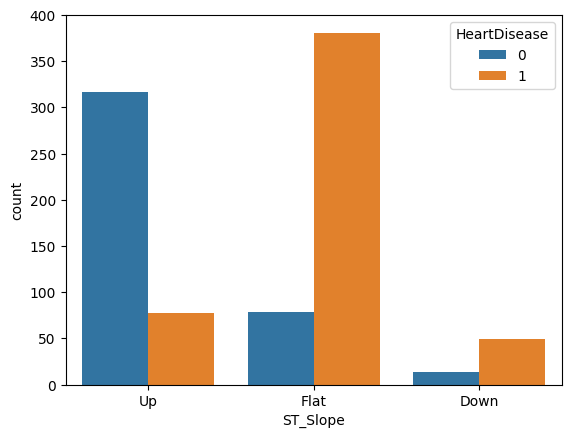

In [225]:
sns.countplot(x="ChestPainType", hue="HeartDisease", data=df_original)
plt.show()

sns.countplot(x="RestingECG", hue="HeartDisease", data=df_original)
plt.show()

sns.countplot(x="ExerciseAngina", hue="HeartDisease", data=df_original)
plt.show()

sns.countplot(x="ST_Slope", hue="HeartDisease", data=df_original)
plt.show()


## 5. Models training

In [226]:
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix


### KNN

In [227]:
from sklearn.neighbors import KNeighborsClassifier


knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)

# Evaluation
acc_knn = accuracy_score(y_test, y_pred)
print("Accuracy:", acc_knn)

print(classification_report(y_test, y_pred))


Accuracy: 0.8478260869565217
              precision    recall  f1-score   support

           0       0.85      0.78      0.81        77
           1       0.85      0.90      0.87       107

    accuracy                           0.85       184
   macro avg       0.85      0.84      0.84       184
weighted avg       0.85      0.85      0.85       184



In [228]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[60 17]
 [11 96]]


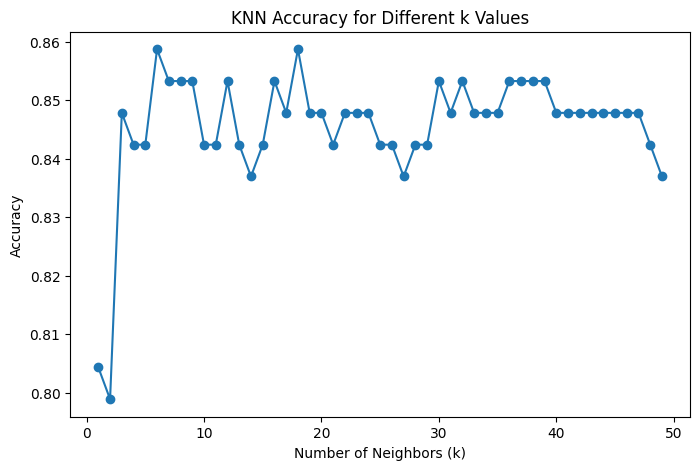

[0.8043478260869565, 0.7989130434782609, 0.8478260869565217, 0.842391304347826, 0.842391304347826, 0.8586956521739131, 0.8532608695652174, 0.8532608695652174, 0.8532608695652174, 0.842391304347826, 0.842391304347826, 0.8532608695652174, 0.842391304347826, 0.8369565217391305, 0.842391304347826, 0.8532608695652174, 0.8478260869565217, 0.8586956521739131, 0.8478260869565217, 0.8478260869565217, 0.842391304347826, 0.8478260869565217, 0.8478260869565217, 0.8478260869565217, 0.842391304347826, 0.842391304347826, 0.8369565217391305, 0.842391304347826, 0.842391304347826, 0.8532608695652174, 0.8478260869565217, 0.8532608695652174, 0.8478260869565217, 0.8478260869565217, 0.8478260869565217, 0.8532608695652174, 0.8532608695652174, 0.8532608695652174, 0.8532608695652174, 0.8478260869565217, 0.8478260869565217, 0.8478260869565217, 0.8478260869565217, 0.8478260869565217, 0.8478260869565217, 0.8478260869565217, 0.8478260869565217, 0.842391304347826, 0.8369565217391305]


In [229]:
k_values = range(1,50)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k).fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

#Plotting
plt.figure(figsize=(8,5))

plt.plot(k_values, accuracies, marker='o')

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy for Different k Values")

plt.show()
print(accuracies)

In [230]:
# With KNN we keep k = 6
knn = KNeighborsClassifier(n_neighbors=6).fit(X_train_scaled, y_train)
y_pred = knn.predict(X_test_scaled)
acc_knn = accuracy_score(y_test, y_pred)
print("Accuracy:", acc_knn)

print(classification_report(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)


Accuracy: 0.8586956521739131
              precision    recall  f1-score   support

           0       0.85      0.81      0.83        77
           1       0.86      0.90      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.85      0.85       184
weighted avg       0.86      0.86      0.86       184

[[62 15]
 [11 96]]


### Logistic Regression

The accuracy and the classification_report of the following model are aceptable for the medical problem.

In [231]:
from sklearn.linear_model import LogisticRegression

LR = LogisticRegression(max_iter=2000)
LR = LR.fit(X_train_scaled, y_train)

y_pred = LR.predict(X_test_scaled)
acc_LR = accuracy_score(y_test, y_pred)
print("Accuracy:", acc_LR)

print(classification_report(y_test, y_pred))


Accuracy: 0.8260869565217391
              precision    recall  f1-score   support

           0       0.84      0.73      0.78        77
           1       0.82      0.90      0.86       107

    accuracy                           0.83       184
   macro avg       0.83      0.81      0.82       184
weighted avg       0.83      0.83      0.82       184



 We will continue trying to improve this results.

In [232]:
# Changing C values:

C_values = [0.01, 0.1 , 1, 10, 100]

for C in C_values:
    LR = LogisticRegression(C=C, max_iter=2000)
    LR = LR.fit(X_train_scaled, y_train)

    y_pred = LR.predict(X_test_scaled)
    acc_LR = accuracy_score(y_test, y_pred)
    print("C =", C, "Accuracy:", acc_LR)



C = 0.01 Accuracy: 0.8260869565217391
C = 0.1 Accuracy: 0.8260869565217391
C = 1 Accuracy: 0.8260869565217391
C = 10 Accuracy: 0.8260869565217391
C = 100 Accuracy: 0.8260869565217391


In [233]:
# Changing C values and penalties:

param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ["l1", "l2"],
    "solver": ["liblinear"]
}

grid = GridSearchCV(LogisticRegression(max_iter=2000), param_grid=param_grid, cv=5) # This aprt searches for the best combination

grid.fit(X_train_scaled, y_train)

print("Best parameters:", grid.best_params_)
best_LR = grid.best_estimator_
y_pred = best_LR.predict(X_test_scaled)
acc_LR = accuracy_score(y_test, y_pred)
print("Best score:", acc_LR)


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2

Best parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best score: 0.8260869565217391


c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2

We got a better result: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}

In [234]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[56 21]
 [11 96]]


### SVC

In [235]:
from sklearn.svm import SVC

param_grid = {
    "C": [0.1, 1],
    "kernel": ["linear"]
    }

grid = GridSearchCV(SVC(), param_grid, cv=5, n_jobs=-1)
grid.fit(X_train_scaled, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1], 'kernel': ['linear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter indexes are 

In [236]:
print("Best parameters:", grid.best_params_)
best_SVC = grid.best_estimator_
y_pred = best_SVC.predict(X_test_scaled)
acc_SVC = accuracy_score(y_test, y_pred)
print("Best score:", acc_SVC)

Best parameters: {'C': 0.1, 'kernel': 'linear'}
Best score: 0.8369565217391305


In [237]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[58 19]
 [11 96]]


### Decision Tree

In [238]:
from sklearn.tree import DecisionTreeClassifier

tree1 = DecisionTreeClassifier(max_depth=3)

tree1 = tree1.fit(X_train, y_train)

y_pred = tree1.predict(X_test)

acc_tree1 = accuracy_score(y_test, y_pred)
print("Accuracy:", acc_tree1)
print(classification_report(y_test, y_pred))

Accuracy: 0.8260869565217391
              precision    recall  f1-score   support

           0       0.81      0.77      0.79        77
           1       0.84      0.87      0.85       107

    accuracy                           0.83       184
   macro avg       0.82      0.82      0.82       184
weighted avg       0.83      0.83      0.83       184



In [239]:
param_grid = {
    "max_depth": [3, 5, 7, 10],
    "min_samples_split": [2, 5, 10],
    "criterion": ["gini", "entropy"]
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    n_jobs=-1
)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 

In [240]:
print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

best_tree = grid.best_estimator_
y_pred = best_tree.predict(X_test)
acc_tree2 = accuracy_score(y_test,y_pred)
print("Accuracy:", acc_tree2)

Best params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Best CV score: 0.8528468921815302
Accuracy: 0.8260869565217391


In [241]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[59 18]
 [14 93]]


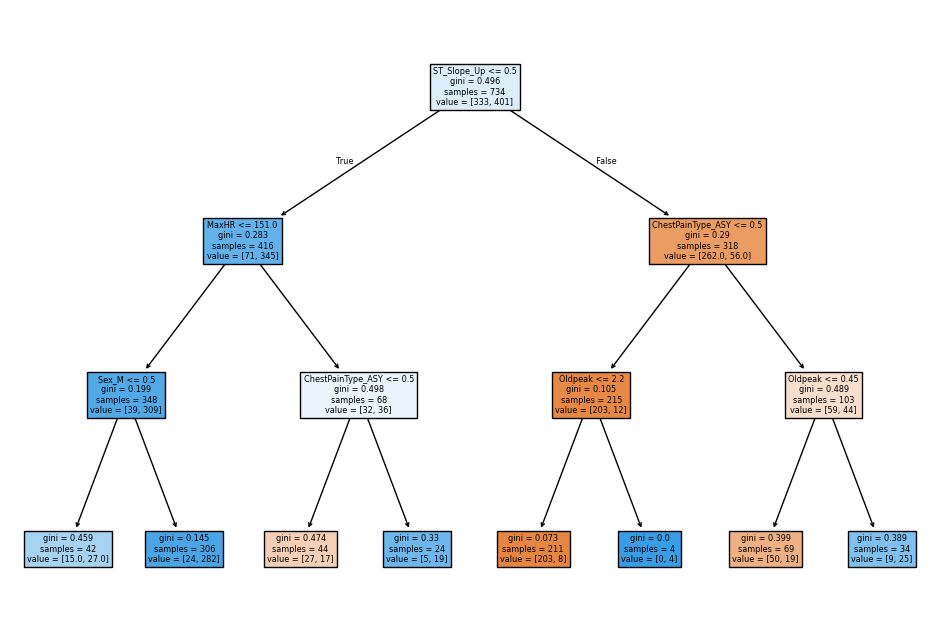

In [242]:
from sklearn.tree import plot_tree

plt.figure(figsize=(12,8))
plot_tree(best_tree, feature_names=X.columns, filled=True)
plt.show()

### Random Forest

In [243]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=0)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8586956521739131
              precision    recall  f1-score   support

           0       0.85      0.81      0.83        77
           1       0.86      0.90      0.88       107

    accuracy                           0.86       184
   macro avg       0.86      0.85      0.85       184
weighted avg       0.86      0.86      0.86       184



In [244]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=0),
    param_grid,
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter can

In [245]:
print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)

best_rf = grid.best_estimator_
y_pred = best_rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred)

print("Accuracy:", acc_rf)

Best params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Best CV score: 0.8842046407604137
Accuracy: 0.8641304347826086


In [246]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[61 16]
 [ 9 98]]


### Naive Bayes

In [247]:
from sklearn.naive_bayes import GaussianNB

nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred = nb.predict(X_test_scaled)

acc_nb = accuracy_score(y_test, y_pred)
print("Accuracy:", acc_nb)

Accuracy: 0.842391304347826


In [248]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[61 16]
 [13 94]]


Naibe Bayes doesn't change by the scale.

### Gradient Boosting

In [249]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()
gb.fit(X_train, y_train)

y_pred = gb.predict(X_test)
acc_gb = accuracy_score(y_test, y_pred)
print("Accuracy:", acc_gb)

Accuracy: 0.8641304347826086


In [250]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[63 14]
 [11 96]]


## 6. Results

The results we got:

In [251]:
print("Accuracies:")
print("knn:", acc_knn)
print("LogisticRegression:", acc_LR)
print("SVC:", acc_SVC)
print("DecisionTree:", acc_tree2)
print("RandomForest:", acc_rf)
print("NaiveBayes:", acc_nb)
print("GradientBoosting", acc_gb)

Accuracies:
knn: 0.8586956521739131
LogisticRegression: 0.8260869565217391
SVC: 0.8369565217391305
DecisionTree: 0.8260869565217391
RandomForest: 0.8641304347826086
NaiveBayes: 0.842391304347826
GradientBoosting 0.8641304347826086


In [252]:
results = pd.DataFrame({
    "Model": ["KNN","Logistic","SVM","DecisionTree","RandomForest","NaiveBayes","GradientBoosting"],
    "Accuracy":[acc_knn, acc_LR, acc_SVC, acc_tree2, acc_rf, acc_nb, acc_gb]
})

print(results.sort_values(by="Accuracy", ascending=False))

              Model  Accuracy
4      RandomForest  0.864130
6  GradientBoosting  0.864130
0               KNN  0.858696
5        NaiveBayes  0.842391
2               SVM  0.836957
1          Logistic  0.826087
3      DecisionTree  0.826087


The highest score was achieved by Random Forest and Gradient Boosting, both with an accuracy of 0.864. However, we prefer Random Forest because it has fewer false negatives (FN = 9) in the confusion matrix. In this context, missing sick people is more critical than incorrectly classifying healthy individuals.

## 7. Conclussion

In this project, several machine learning models were evaluated to predict the presence of heart disease using the dataset features. Among the tested models, Random Forest and Gradient Boosting achieved the highest accuracy, both reaching 0.864.

However, when analyzing the confusion matrix, Random Forest produced fewer false negatives (FN = 9) compared to Gradient Boosting (FN = 11). In the context of medical diagnosis, false negatives are particularly critical, since they represent sick patients who are incorrectly classified as healthy.

For this reason, Random Forest was selected as the preferred model, as it reduces the risk of missing individuals who may have heart disease.